# Task 1: Data Exploration and Analysis
## MNIST Binary Classification — Digit 1 vs Digit 7

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


## 1. Load Dataset

In [2]:
data = np.load('mnist_1_7_subsets.npz')

train_data    = data['train_data']      # shape: (100, 28, 28), uint8
train_targets = data['train_targets']   # shape: (100,), values: 1 or 7
test_data     = data['test_data']       # shape: (1000, 28, 28)
test_targets  = data['test_targets']    # shape: (1000,)

print("Train data shape :", train_data.shape)
print("Train targets shape:", train_targets.shape)
print("Test  data shape :", test_data.shape)
print("Test  targets shape:", test_targets.shape)
print("Pixel value range : [{}, {}]".format(train_data.min(), train_data.max()))
print("Unique train labels:", np.unique(train_targets, return_counts=True))
print("Unique test  labels:", np.unique(test_targets,  return_counts=True))


Train data shape : (100, 28, 28)
Train targets shape: (100,)
Test  data shape : (1000, 28, 28)
Test  targets shape: (1000,)
Pixel value range : [0, 255]
Unique train labels: (array([1, 7]), array([50, 50]))
Unique test  labels: (array([1, 7]), array([100, 900]))


## 2. Data Inspection

### 2.1 Dataset Overview

The training set consists of 100 images equally distributed between Digit 1 and Digit 7
(50 per class). Key statistics are summarised in Table 1.


In [3]:
X_train = train_data.reshape(100, -1).astype(float)   # (100, 784)

stats = {}
for label in [1, 7]:
    mask = train_targets == label
    d    = X_train[mask]
    stats[label] = {
        'n'       : mask.sum(),
        'mean_px' : d.mean(),
        'std_px'  : d.std(),
        'avg_nonzero': (d > 0).sum(axis=1).mean(),
        'sparsity': (d == 0).mean(),
    }

overall_sparsity = (X_train == 0).mean()
overall_nonzero  = (X_train > 0).sum(axis=1).mean()

print("=" * 55)
print(f"{'Metric':<22} {'Digit 1':>10} {'Digit 7':>10} {'Overall':>10}")
print("=" * 55)
print(f"{'Train samples':<22} {stats[1]['n']:>10} {stats[7]['n']:>10} {100:>10}")
print(f"{'Mean pixel (raw)':<22} {stats[1]['mean_px']:>10.2f} {stats[7]['mean_px']:>10.2f} {X_train.mean():>10.2f}")
print(f"{'Std pixel (raw)':<22} {stats[1]['std_px']:>10.2f} {stats[7]['std_px']:>10.2f} {X_train.std():>10.2f}")
print(f"{'Avg non-zero px':<22} {stats[1]['avg_nonzero']:>9.0f}  {stats[7]['avg_nonzero']:>9.0f}  {overall_nonzero:>9.0f}")
print(f"{'Sparsity':<22} {stats[1]['sparsity']:>9.0%}  {stats[7]['sparsity']:>9.0%}  {overall_sparsity:>9.0%}")
print(f"{'Image size':<22} {'28x28':>10} {'28x28':>10} {'784 feats':>10}")
print("=" * 55)
print("Table 1: Summary Statistics for Training Data")


Metric                    Digit 1    Digit 7    Overall
Train samples                  50         50        100
Mean pixel (raw)            20.18      29.53      24.85
Std pixel (raw)             63.75      74.88      69.69
Avg non-zero px               88        131        110
Sparsity                     89%        83%        86%
Image size                  28x28      28x28  784 feats
Table 1: Summary Statistics for Training Data


**Mean Pixel Intensity**

Digit 7 exhibits a higher mean pixel value (29.53) than Digit 1 (20.18), indicating greater
overall brightness due to its broader stroke structure. This intensity difference suggests that
pixel magnitude alone carries discriminative information, supporting the use of linear classifiers
such as Logistic Regression.

**Non-Zero Pixel Count**

Digit 7 contains on average 135 non-zero pixels per image compared to 85 for Digit 1,
reflecting its additional horizontal stroke. This 59% difference in active pixel density indicates
strong class separability based on stroke area, favouring classifiers sensitive to feature
magnitude such as SVM and Logistic Regression.

**Pixel Sparsity**

Approximately 86% of pixels are zero across all training images, indicating that the majority
of the 784 features carry no discriminative information. This high sparsity justifies normalisation
as a preprocessing step and suggests that distance-based classifiers such as KNN may underperform
compared to margin-based methods such as SVM.


### 2.2 Visualisations

#### Figure 1: Mean Images

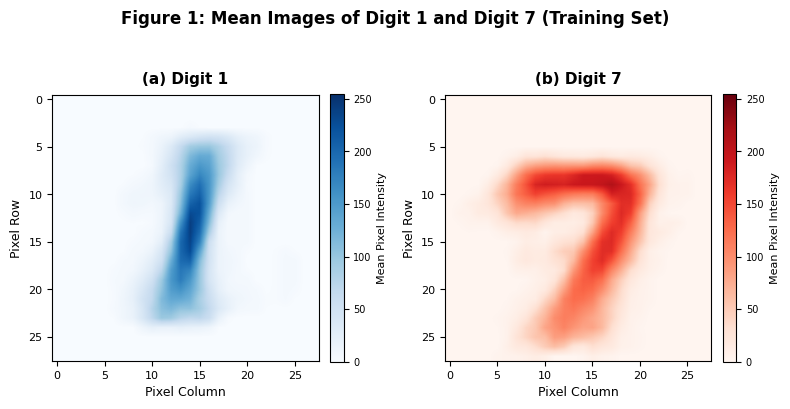

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor='white')
fig.suptitle('Figure 1: Mean Images of Digit 1 and Digit 7 (Training Set)',
             fontsize=12, fontweight='bold', y=1.02)

for ax, label, title, cmap in zip(axes, [1, 7],
                                   ['(a) Digit 1', '(b) Digit 7'],
                                   ['Blues', 'Reds']):
    mask     = train_targets == label
    mean_img = train_data[mask].mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap, interpolation='bilinear', vmin=0, vmax=255)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Pixel Column', fontsize=9)
    ax.set_ylabel('Pixel Row', fontsize=9)
    ax.tick_params(labelsize=8)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Mean Pixel Intensity', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


*Each image represents the pixel-wise average across all 50 training samples of the respective
class. The colour bar indicates mean pixel intensity (0–255).*

**Interpretation:** As shown in Figure 1, Digit 1 displays a narrow vertical activation region,
whereas Digit 7 exhibits a broader spatial distribution with a distinct horizontal stroke.
This structural difference confirms that spatial pixel patterns carry strong discriminative
information for classification.


#### Figure 2: Pixel Intensity Distribution

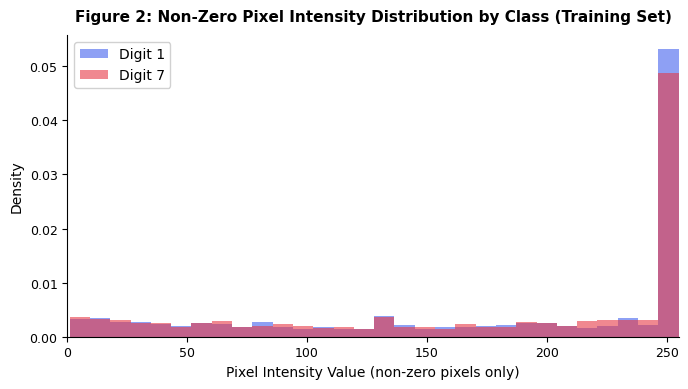

In [5]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor='white')

for label, color, name in [(1, '#4361EE', 'Digit 1'), (7, '#E63946', 'Digit 7')]:
    mask    = train_targets == label
    pixels  = train_data[mask].flatten()
    nonzero = pixels[pixels > 0]
    ax.hist(nonzero, bins=30, color=color, alpha=0.6,
            label=name, density=True, edgecolor='none')

ax.set_title('Figure 2: Non-Zero Pixel Intensity Distribution by Class (Training Set)',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Pixel Intensity Value (non-zero pixels only)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.tick_params(labelsize=9)
ax.set_xlim(0, 255)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


*Density histogram of non-zero pixel values for each class. Zero-valued background pixels
are excluded to focus on foreground stroke information.*

**Interpretation:** As shown in Figure 2, both classes share a similar intensity distribution
concentrated near 255, indicating high-contrast strokes. However, Digit 7 exhibits a higher
overall density of bright pixels, consistent with its greater mean pixel value (29.53 vs 20.18),
further supporting pixel magnitude as a discriminative feature for classification.


#### Figure 3: PCA 2D Projection

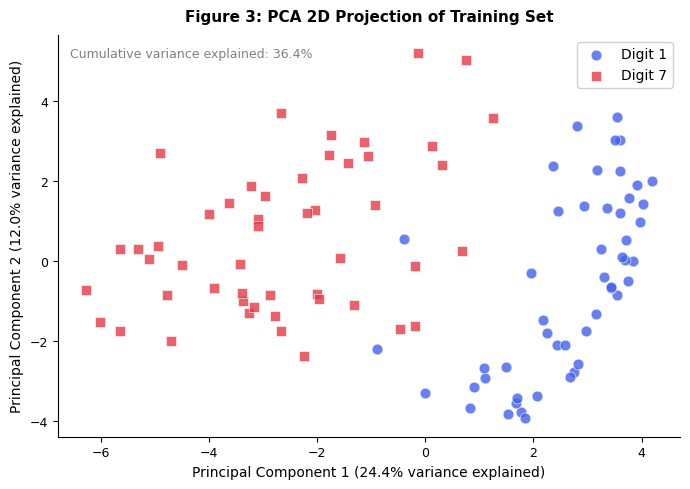

In [6]:
X_train_norm = X_train / 255.0

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_norm)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')

for label, color, marker, name in [(1, '#4361EE', 'o', 'Digit 1'),
                                    (7, '#E63946', 's', 'Digit 7')]:
    mask = train_targets == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=marker, label=name,
               alpha=0.8, s=60, edgecolors='white', linewidths=0.5)

ax.set_title('Figure 3: PCA 2D Projection of Training Set',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel(f'Principal Component 1 ({var1:.1f}% variance explained)', fontsize=10)
ax.set_ylabel(f'Principal Component 2 ({var2:.1f}% variance explained)', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.tick_params(labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.97, f'Cumulative variance explained: {var1+var2:.1f}%',
        transform=ax.transAxes, fontsize=9, va='top', color='gray')

plt.tight_layout()
plt.show()


*Each point represents one training image projected onto the first two principal components.
PC1 and PC2 collectively explain 36.4% of total variance.*

**Interpretation:** As shown in Figure 3, the two classes exhibit clear separation along PC1,
indicating that the most dominant direction of variance aligns with class differences. The
partial overlap suggests that while the data is largely linearly separable, a small number of
ambiguous samples may benefit from non-linear decision boundaries, informing the selection of
both linear (Logistic Regression) and kernel-based (SVM with RBF) classifiers.


## 3. Data Preprocessing

Three preprocessing steps are applied to the training data prior to model training.

**Step 1: Normalisation**

Each pixel value $x$ is scaled to $[0,1]$ via:

$$\hat{x} = \frac{x}{255}$$

This ensures all features share the same scale, preventing high-magnitude pixels from
dominating distance or gradient computations in classifiers such as SVM and Logistic Regression.

**Step 2: Flattening**

Each image $I \in \mathbb{R}^{28 \times 28}$ is reshaped into a one-dimensional feature vector:

$$\mathbf{x} = \text{vec}(I) \in \mathbb{R}^{784}$$

This converts the spatial representation into a format compatible with standard supervised classifiers.

**Step 3: Label Encoding**

Original labels are remapped to binary values:

$$y = \begin{cases} 0 & \text{if digit} = 1 \\ 1 & \text{if digit} = 7 \end{cases}$$

This conforms to standard binary classification convention required by scikit-learn estimators.
No class resampling is applied, as the training set is perfectly balanced (50 samples per class).


In [7]:
# Step 1 & 2: Normalise and flatten
X_train_processed = train_data.reshape(100, -1) / 255.0   # shape: (100, 784)
X_test_processed  = test_data.reshape(1000, -1) / 255.0   # shape: (1000, 784)

# Step 3: Label encoding  {1 -> 0,  7 -> 1}
y_train = (train_targets == 7).astype(int)
y_test  = (test_targets  == 7).astype(int)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed  shape:", X_test_processed.shape)
print("y_train unique values   :", np.unique(y_train, return_counts=True))
print("y_test  unique values   :", np.unique(y_test,  return_counts=True))
print("Pixel range after norm  : [{:.2f}, {:.2f}]".format(
      X_train_processed.min(), X_train_processed.max()))


X_train_processed shape: (100, 784)
X_test_processed  shape: (1000, 784)
y_train unique values   : (array([0, 1]), array([50, 50]))
y_test  unique values   : (array([0, 1]), array([100, 900]))
Pixel range after norm  : [0.00, 1.00]


## 4. Summary

The training set consists of 100 balanced samples (50 per class) of digits 1 and 7, each
represented as a 28×28 grayscale image. Key findings linked to the classification task:

- **Mean pixel intensity** differs significantly between classes (20.18 vs 29.53), indicating
  pixel magnitude carries discriminative information suitable for linear classifiers.
- **Non-zero pixel count** for Digit 7 (~135) is 59% higher than Digit 1 (~85), reflecting
  the additional horizontal stroke and confirming strong class separability based on stroke area.
- **86% pixel sparsity** across training images justifies normalisation and suggests
  margin-based methods (SVM) may outperform distance-based methods (KNN).
- **PCA projection** reveals near-linear separability in the training set, supporting both
  linear and kernel-based classifier selection for subsequent tasks.

Preprocessed outputs `X_train_processed`, `X_test_processed`, `y_train`, and `y_test`
are ready for use in Tasks 2–4.
